# Steam Games Exploratory Data Analysis

This notebook explores the `steam_games.json` snapshot of Steam's store catalog. Each row describes a title with metadata such as genre, tags, price, discount status, release dates, review sentiment, and metascore. The goals are to understand data quality, pricing patterns, release trends, and the most common genres/tags represented in the dataset.

## Part 1: Steam catalog exploration

Understand the structure and pricing/release dynamics of the `steam_games.json` snapshot before building any predictive model.


In [4]:
import ast
import gzip
from itertools import islice
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 5)
DATA_PATH = Path('data/steam_games.json')


In [5]:
from itertools import islice
import gzip

def peek_json_gz(path, n=3):
    """Return column names and sample rows from a JSON Lines gzip file."""
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        sample = [ast.literal_eval(line) for line in islice(f, n)]
    columns = sorted({key for row in sample for key in row})
    return columns, sample


## Load and inspect the raw dataset

In [6]:
rows = []
with DATA_PATH.open() as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(ast.literal_eval(line))

df = pd.DataFrame(rows)
print(f"Loaded {len(df):,} games with {df.shape[1]} columns")
df.head()


Loaded 32,135 games with 16 columns


,publisher,genres,app_name,title,url,release_date,tags,discount_price,reviews_url,specs,price,early_access,id,developer,sentiment,metascore
0,Kotoshiro,"[Action, Casual, Indie, Simulation, Strategy]",Lost Summoner Kitty,Lost Summoner Kitty,http://store.steampowered.com/app/761140/Lost_...,2018-01-04,"[Strategy, Action, Indie, Casual, Simulation]",4.49,http://steamcommunity.com/app/761140/reviews/?...,[Single-player],4.99,False,761140,Kotoshiro,NaN,NaN
1,"Making Fun, Inc.","[Free to Play, Indie, RPG, Strategy]",Ironbound,Ironbound,http://store.steampowered.com/app/643980/Ironb...,2018-01-04,"[Free to Play, Strategy, Indie, RPG, Card Game...",NaN,http://steamcommunity.com/app/643980/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free To Play,False,643980,Secret Level SRL,Mostly Positive,NaN
2,Poolians.com,"[Casual, Free to Play, Indie, Simulation, Sports]",Real Pool 3D - Poolians,Real Pool 3D - Poolians,http://store.steampowered.com/app/670290/Real_...,2017-07-24,"[Free to Play, Simulation, Sports, Casual, Ind...",NaN,http://steamcommunity.com/app/670290/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free to Play,False,670290,Poolians.com,Mostly Positive,NaN
3,彼岸领域,"[Action, Adventure, Casual]",弹炸人2222,弹炸人2222,http://store.steampowered.com/app/767400/2222/,2017-12-07,"[Action, Adventure, Casual]",0.83,http://steamcommunity.com/app/767400/reviews/?...,[Single-player],0.99,False,767400,彼岸领域,NaN,NaN
4,NaN,NaN,Log Challenge,NaN,http://store.steampowered.com/app/773570/Log_C...,NaN,"[Action, Indie, Casual, Sports]",1.79,http://steamcommunity.com/app/773570/reviews/?...,"[Single-player, Full controller support, HTC V...",2.99,False,773570,NaN,NaN,NaN


In [7]:
df.dtypes.to_frame('dtype')


,dtype
publisher,object
genres,object
app_name,object
title,object
url,object
release_date,object
tags,object
discount_price,float64
reviews_url,object
specs,object


In [8]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
missing_pct.to_frame('pct_missing')


,pct_missing
discount_price,99.299829
metascore,91.669519
publisher,25.056792
sentiment,22.349463
developer,10.266065
genres,10.216275
release_date,6.432239
title,6.379337
price,4.285047
specs,2.084954


## Data cleaning and feature engineering

In [ ]:
def parse_price(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return np.nan
        if value.lower().startswith('free'):
            return 0.0
        value = value.replace('$', '')
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

df['price_numeric'] = df['price'].apply(parse_price)
df['discount_numeric'] = df['discount_price'].apply(lambda x: float(x) if pd.notnull(x) else np.nan)
df['discount_pct'] = np.where(
    df['discount_numeric'].notna() & df['price_numeric'].notna() & (df['price_numeric'] > 0),
    (1 - df['discount_numeric'] / df['price_numeric']).clip(lower=0),
    np.nan, 
)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['metascore'] = pd.to_numeric(df['metascore'], errors='coerce')

df[['price', 'price_numeric', 'discount_price', 'discount_numeric', 'discount_pct', 'release_date', 'metascore']].head()


,price,price_numeric,discount_price,discount_numeric,discount_pct,release_date,release_year,metascore
0,4.99,4.99,4.49,4.49,0.100200,2018-01-04,2018.0,NaN
1,Free To Play,0.00,NaN,NaN,NaN,2018-01-04,2018.0,NaN
2,Free to Play,0.00,NaN,NaN,NaN,2017-07-24,2017.0,NaN
3,0.99,0.99,0.83,0.83,0.161616,2017-12-07,2017.0,NaN
4,2.99,2.99,1.79,1.79,0.401338,NaT,NaN,NaN


## Pricing overview

In [12]:
price_summary = df['price_numeric'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
free_share = (df['price_numeric'] == 0).mean() * 100
paid_share = 100 - free_share
print(price_summary)
print(f'\nFree-to-play share: {free_share:.1f}% | Paid share: {paid_share:.1f}%')


count    30746.000000
mean         8.870315
std         15.905595
min          0.000000
25%          2.990000
50%          4.990000
75%          9.990000
90%         19.990000
95%         24.990000
max        995.000000
Name: price_numeric, dtype: float64

Free-to-play share: 5.9% | Paid share: 94.1%


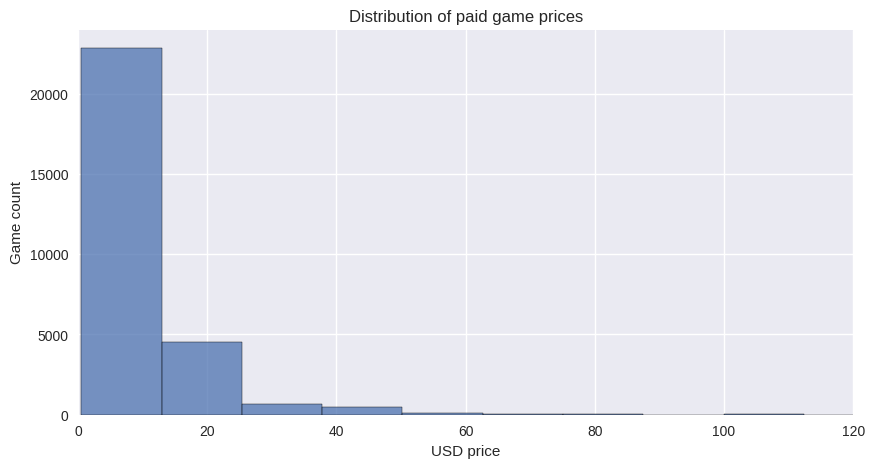

In [13]:
paid_prices = df.loc[df['price_numeric'] > 0, 'price_numeric']
fig, ax = plt.subplots()
sns.histplot(paid_prices, bins=80, ax=ax)
ax.set_title('Distribution of paid game prices')
ax.set_xlabel('USD price')
ax.set_ylabel('Game count')
ax.set_xlim(0, 120)
plt.show()


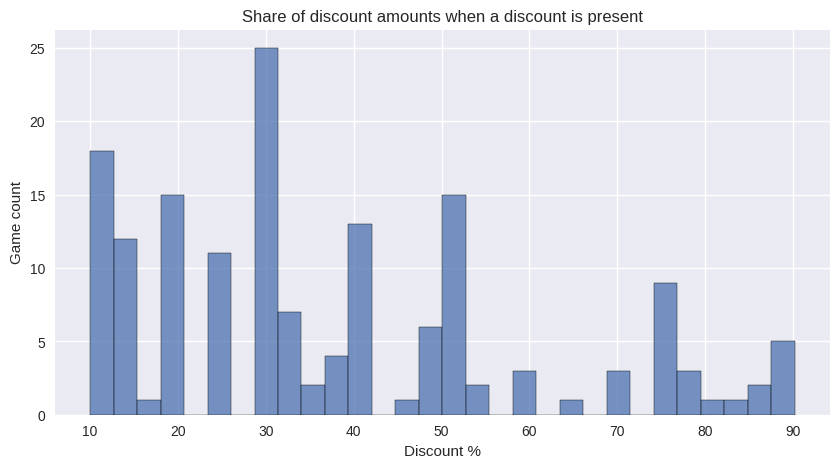

In [14]:
fig, ax = plt.subplots()
sns.histplot(df['discount_pct'].dropna() * 100, bins=30, ax=ax)
ax.set_title('Share of discount amounts when a discount is present')
ax.set_xlabel('Discount %')
ax.set_ylabel('Game count')
plt.show()


## Review trends

In [11]:
sentiment_counts = df['sentiment'].fillna('Unknown').value_counts()
sentiment_counts.to_frame('count')


                         count
sentiment                     
Unknown                   7182
Mixed                     4103
Very Positive             3868
Positive                  3281
Mostly Positive           2744
1 user reviews            2496
2 user reviews            1756
3 user reviews            1231
4 user reviews             964
5 user reviews             846
Mostly Negative            802
6 user reviews             756
7 user reviews             619
8 user reviews             537
9 user reviews             488
Overwhelmingly Positive    303
Negative                   123
Very Negative               29
Overwhelmingly Negative      7

## Genres, tags, and specs

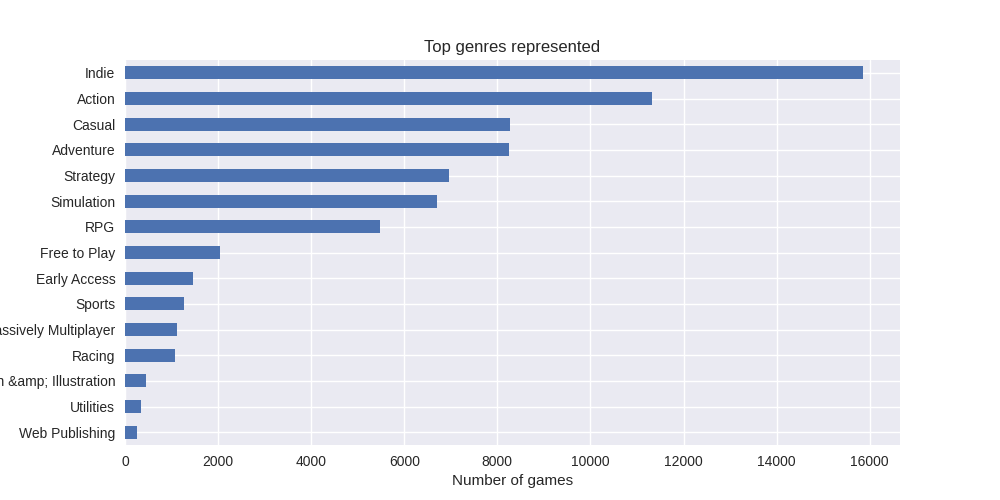

In [12]:
genre_counts = df['genres'].dropna().explode().value_counts().head(15)
fig, ax = plt.subplots()
genre_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Number of games')
ax.set_title('Top genres represented')
plt.show()


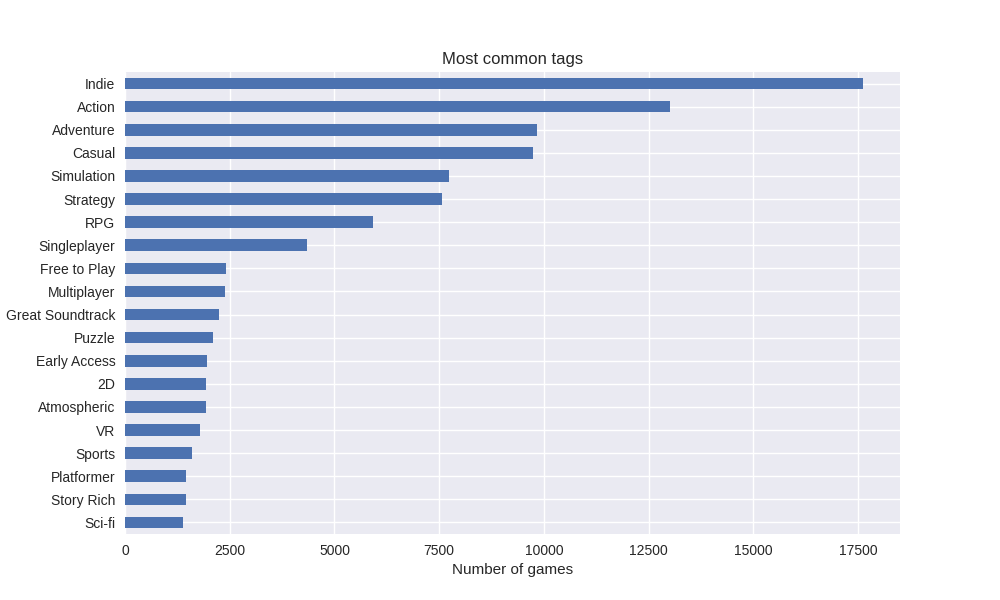

In [13]:
tag_counts = df['tags'].dropna().explode().value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
tag_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Number of games')
ax.set_title('Most common tags')
plt.show()


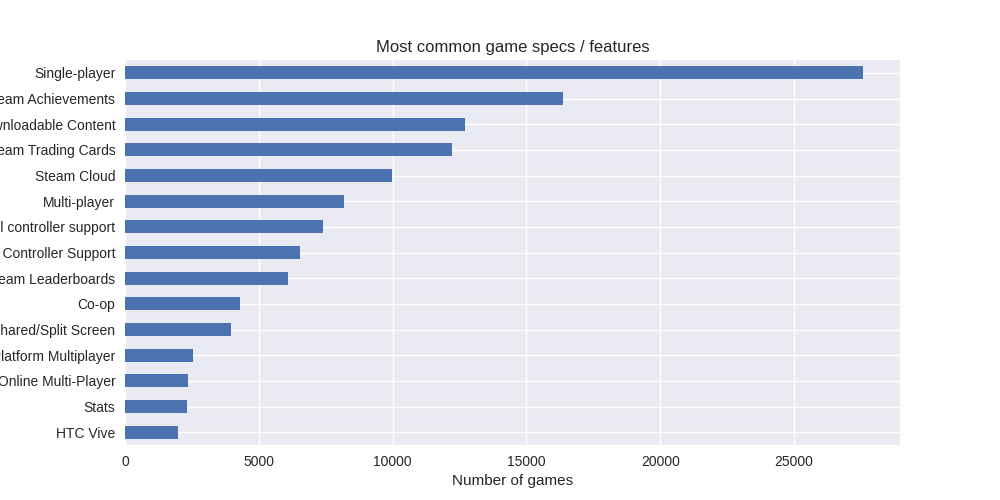

In [14]:
spec_counts = df['specs'].dropna().explode().value_counts().head(15)
ax = spec_counts.sort_values().plot(kind='barh')
ax.set_xlabel('Number of games')
ax.set_title('Most common game specs / features')
plt.show()


## Part 2: Review data preparation and modeling

Flatten the review snapshots, engineer per-game and per-user features, and build the recommendation predictor.


## User review recommendation analysis

Examine recommendation behavior within the Australian user review snapshot and relate it to Steam catalog features.


In [15]:
import gzip

REVIEWS_PATH = Path('data/australian_user_reviews.json.gz')
review_entries = []
with gzip.open(REVIEWS_PATH, 'rt', encoding='utf-8') as f:
    for line in f:
        review_entries.append(ast.literal_eval(line))

rows = []
for entry in review_entries:
    user_id = entry.get('user_id')
    user_url = entry.get('user_url')
    for review in entry.get('reviews', []):
        record = {
            'user_id': user_id,
            'user_url': user_url,
            'item_id': review.get('item_id'),
            'posted': review.get('posted'),
            'last_edited': review.get('last_edited'),
            'recommend': bool(review.get('recommend')),
            'helpful': review.get('helpful'),
            'funny': review.get('funny'),
            'review': review.get('review'),
        }
        rows.append(record)

df_reviews = pd.DataFrame(rows)
df_reviews['recommend_flag'] = df_reviews['recommend'].astype(int)
print(f"Loaded {len(df_reviews):,} flattened reviews from {len(review_entries):,} users")
df_reviews.head()


Loaded 59,305 flattened reviews from 25,799 users


,user_id,user_url,item_id,posted,last_edited,recommend,helpful,funny,review,recommend_flag
0,76561197970982479,http://steamcommunity.com/profiles/76561197970...,1250,"Posted November 5, 2011.",,True,No ratings yet,,Simple yet with great replayability. In my opi...,1
1,76561197970982479,http://steamcommunity.com/profiles/76561197970...,22200,"Posted July 15, 2011.",,True,No ratings yet,,It's unique and worth a playthrough.,1
2,76561197970982479,http://steamcommunity.com/profiles/76561197970...,43110,"Posted April 21, 2011.",,True,No ratings yet,,Great atmosphere. The gunplay can be a bit chu...,1
3,js41637,http://steamcommunity.com/id/js41637,251610,"Posted June 24, 2014.",,True,15 of 20 people (75%) found this review helpful,,I know what you think when you see this title ...,1
4,js41637,http://steamcommunity.com/id/js41637,227300,"Posted September 8, 2013.",,True,0 of 1 people (0%) found this review helpful,,For a simple (it's actually not all that simpl...,1


In [16]:
recommend_counts = df_reviews['recommend'].value_counts().rename_axis('recommend')
recommend_pct = (recommend_counts / recommend_counts.sum() * 100).round(2)
distribution = pd.DataFrame({'count': recommend_counts, 'percent': recommend_pct})
distribution


,count,percent
recommend,,
True,52473,88.48
False,6832,11.52


### Catalog feature correlation with recommendations

Associate each review with Steam catalog metadata and compute Pearson correlations between the binary recommendation flag and numeric features.


In [35]:

if 'df' not in globals():
    raise RuntimeError('Steam games DataFrame `df` is not defined. Run the earlier loading cell first.')

feature_cols = ['price_numeric', 'discount_pct', 'release_year', 'metascore']
merge_cols = feature_cols + ['early_access', 'tags', 'specs', 'developer', 'genres']
review_features = df_reviews.merge(
    df[['id'] + merge_cols],
    left_on='item_id',
    right_on='id',
    how='left'
)

correlations = {}
for col in feature_cols:
    pair = review_features[['recommend_flag', col]].dropna()
    if len(pair) < 10:
        correlations[col] = float('nan')
    else:
        correlations[col] = pair.corr().iloc[0, 1]

corr = pd.Series(correlations)

categorical_summary = review_features.groupby('early_access')['recommend_flag'].agg(['mean','count'])
print('Pearson correlation with recommend flag (pairwise, drop NA):')
print(corr)
print()
print('Early access recommendation rates:')
categorical_summary


Pearson correlation with recommend flag (pairwise, drop NA):
price_numeric   -0.054237
discount_pct     0.179370
release_year    -0.116135
metascore        0.183148
dtype: float64

Early access recommendation rates:


,mean,count
early_access,,
False,0.896485,51017
True,0.831370,2971


### Recommendation rates across categorical catalog features

Explode multi-valued catalog attributes and compare recommendation rates for frequently occurring categories (minimum 50 linked reviews).


In [36]:

if 'review_features' not in globals():
    raise RuntimeError('Run the previous merge cell to create `review_features`.')

cat_configs = [
    ('tags', True, 'Top tags'),
    ('genres', True, 'Top genres'),
    ('specs', True, 'Top specs / features'),
    ('developer', False, 'Top developers')
]

categorical_results = {}
for field, is_list, label in cat_configs:
    data = review_features[['recommend_flag', field]].dropna()
    if is_list:
        data = data.explode(field)
    summary = (
        data.groupby(field)['recommend_flag']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'recommend_rate'})
        .sort_values('recommend_rate', ascending=False)
    )
    summary = summary[summary['count'] >= 50]
    categorical_results[label] = summary.head(15)
    print(label)
    print(summary.head(10))

categorical_results


Top tags
                                   recommend_rate  count
tags                                                    
Dynamic Narration                        0.986486    222
Science                                  0.978261    736
Score Attack                             0.972093    430
1980s                                    0.971867    391
Music-Based Procedural Generation        0.970297    101
Animation & Modeling                     0.968156   1947
Satire                                   0.967960    593
Lara Croft                               0.966480    179
Cartoon                                  0.965378   4217
Stylized                                 0.963589    769
Top genres
                          recommend_rate  count
genres                                         
Video Production                0.946667    150
Animation &amp; Modeling        0.941935    155
Utilities                       0.901961     51
Indie                           0.894463  22068
Simulati

{'Top tags':                                    recommend_rate  count
 tags                                                    
 Dynamic Narration                        0.986486    222
 Science                                  0.978261    736
 Score Attack                             0.972093    430
 1980s                                    0.971867    391
 Music-Based Procedural Generation        0.970297    101
 Animation & Modeling                     0.968156   1947
 Satire                                   0.967960    593
 Lara Croft                               0.966480    179
 Cartoon                                  0.965378   4217
 Stylized                                 0.963589    769
 Diplomacy                                0.962193    529
 Political                                0.961595    677
 Agriculture                              0.959184    147
 Time Manipulation                        0.957983    238
 Cartoony                                 0.956784   4304,
 

### User niceness scores

Compute a user-level "niceness" metric using the provided exponential weighting based on each game's recommendation rate. Users without reviews fall back to the global expected value.


In [37]:

if 'df_reviews' not in globals():
    raise RuntimeError('Run the review flattening cell first to create `df_reviews`.')

# Game-level recommendation rate
item_rates = df_reviews.groupby('item_id')['recommend_flag'].mean().rename('game_recommend_rate')
rate_multiplier = np.exp(1 - item_rates)
global_default = (rate_multiplier * item_rates).mean()

# Attach rates to each review
reviews_with_rates = df_reviews.merge(item_rates, left_on='item_id', right_index=True, how='left')
reviews_with_rates['game_recommend_rate'] = reviews_with_rates['game_recommend_rate'].fillna(item_rates.mean())
reviews_with_rates['weighted_score'] = np.exp(1 - reviews_with_rates['game_recommend_rate']) * reviews_with_rates['recommend_flag']

user_scores = reviews_with_rates.groupby('user_id')['weighted_score'].mean().rename('niceness_score')
all_users = pd.Index([entry.get('user_id') for entry in review_entries]).dropna().unique()
niceness_df = pd.DataFrame({'user_id': all_users})
niceness_df['niceness_score'] = niceness_df['user_id'].map(user_scores).fillna(global_default)

fallback_count = niceness_df['niceness_score'].eq(global_default).sum()
percentage = fallback_count / len(niceness_df) * 100
print(f'Users with fallback niceness: {fallback_count:,} / {len(niceness_df):,} ({percentage:.2f}%)')

print(f'Computed niceness for {len(niceness_df):,} users; fallback score = {global_default:.4f}')
niceness_df['niceness_score'].describe()


Users with fallback niceness: 27 / 25,485 (0.11%)
Computed niceness for 25,485 users; fallback score = 0.8677


count    25485.000000
mean         0.984379
std          0.291516
min          0.000000
25%          1.008054
50%          1.049019
75%          1.094421
max          2.339647
Name: niceness_score, dtype: float64

### Logistic regression prediction of recommendations

Train a simple logistic regression model using catalog features (price, discounts, release year, metascore, early access flag) to predict whether a user recommended the game.


### Features included in the model

- **Numeric catalog attributes:** cleaned price, discount percentage, release year, Metacritic score, and the exponential niceness score computed per user.
- **Binary attributes:** early-access flag plus one-hot indicators for the most common tags, specs, genres, and developers (only categories covering at least 1% of modeled reviews).
- **Target:** whether the flattened review recommended the game (`recommend_flag`).
- **Derived `price_actual`: combines list price with observed discounts via `price_numeric * (1 - discount_pct)` to approximate what players actually pay.


In [44]:

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

if 'niceness_df' not in globals() or 'global_default' not in globals():
    raise RuntimeError('Run the niceness score section before training the logistic regression.')

review_features['discount_pct'] = review_features['discount_pct'].fillna(0)
review_features['price_actual'] = review_features['price_numeric'] * (1 - review_features['discount_pct'].clip(upper=0.99))
model_features = ['user_id', 'price_actual', 'discount_pct', 'metascore', 'early_access', 'tags', 'specs', 'genres', 'developer']
essential_features = ['price_actual', 'tags']
model_df = review_features[model_features + ['recommend_flag']].dropna(subset=essential_features).copy()
model_df = model_df.merge(niceness_df[['user_id', 'niceness_score']], on='user_id', how='left')
model_df['niceness_score'] = model_df['niceness_score'].fillna(global_default)
model_df['metascore'] = model_df['metascore'].fillna(model_df['metascore'].median())
model_df['developer'] = model_df['developer'].fillna('Unknown')
model_df['early_access_flag'] = model_df['early_access'].fillna(False).astype(int)

cat_threshold = max(1, int(0.01 * len(model_df)))

def top_values(series, threshold):
    counts = series.value_counts()
    return counts[counts >= threshold].index.tolist()

all_tag_counts = review_features['tags'].dropna().explode()
all_spec_counts = review_features['specs'].dropna().explode()
all_genre_counts = review_features['genres'].dropna().explode()

top_tags = top_values(all_tag_counts, cat_threshold)
top_specs = top_values(all_spec_counts, cat_threshold)
top_genres = top_values(all_genre_counts, cat_threshold)
top_devs = top_values(review_features['developer'].fillna('Unknown'), cat_threshold)

cat_feature_frames = []

def multi_hot(df, column, values, prefix):
    data = {
        f"{prefix}_{value}": df[column].apply(lambda items, v=value: int(isinstance(items, list) and v in items))
        for value in values
    }
    return pd.DataFrame(data, index=df.index)

if top_tags:
    cat_feature_frames.append(multi_hot(model_df, 'tags', top_tags, 'tag'))
if top_specs:
    cat_feature_frames.append(multi_hot(model_df, 'specs', top_specs, 'spec'))
if top_genres:
    cat_feature_frames.append(multi_hot(model_df, 'genres', top_genres, 'genre'))
if top_devs:
    dev_data = pd.DataFrame({f'developer_{dev}': (model_df['developer'] == dev).astype(int) for dev in top_devs}, index=model_df.index)
    cat_feature_frames.append(dev_data)

if cat_feature_frames:
    cat_features_df = pd.concat(cat_feature_frames, axis=1)
else:
    cat_features_df = pd.DataFrame(index=model_df.index)

cat_features_df['early_access_flag'] = model_df['early_access_flag']

numeric_features = ['price_actual', 'discount_pct', 'metascore', 'niceness_score']
cat_feature_cols = list(cat_features_df.columns)
all_features = numeric_features + cat_feature_cols
X = pd.concat([model_df[numeric_features], cat_features_df], axis=1)
y = model_df['recommend_flag']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', cat_feature_cols)
    ]
)

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', penalty='l2', solver='lbfgs'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print(f'Accuracy: {accuracy:.3f}')
print(f'ROC AUC: {roc_auc:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=3))

coefs = pipeline.named_steps['logreg'].coef_[0]
feature_names = numeric_features + cat_feature_cols
coef_table = (
    pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    .sort_values('coefficient', key=lambda s: s.abs(), ascending=False)
)
coef_table



/tmp/ipykernel_907227/3860314062.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df['early_access_flag'] = model_df['early_access'].fillna(False).astype(int)


Accuracy: 0.894
ROC AUC: 0.955

Classification report:
              precision    recall  f1-score   support

           0      0.501     0.869     0.636      1130
           1      0.983     0.897     0.938      9522

    accuracy                          0.894     10652
   macro avg      0.742     0.883     0.787     10652
weighted avg      0.932     0.894     0.906     10652



,feature,coefficient
3,niceness_score,2.525804
233,developer_Re-Logic,1.849105
176,tag_Satire,1.815810
136,tag_4 Player Local,1.340564
158,tag_Science,1.280939
...,...,...
27,tag_Survival,-0.011156
120,tag_Destruction,-0.010552
82,tag_Retro,0.010312
157,tag_Arena Shooter,0.001937
